# Iteration 7: Stakeholder Summary

## 1. Scorecard (Model 2: Emb + Meta + Topics)
*   **MAE (training):**
*   **MAE (validation):**
*   **R-Squared (training):**
*   **R-Squared (validation):**


## 2. Key Findings
* ...


## 3. Next Steps
*   **Item 01**

#Baseline model

In [ ]:
## CHUNK : BASELINE


import pandas as pd
import numpy as np
import os

path = '/content/drive/MyDrive/Research/2025 Beacon/202601 Workshop results/Lonza_Unified_Engineered.csv'

if os.path.exists(path):
    df_unified = pd.read_csv(path)
    print("Loaded df_unified from CSV.")

    # Robust Embedding Parser
    def parse_embedding(x):
        if isinstance(x, str):
            # Clean string: remove brackets and newlines
            x_clean = x.replace('[', '').replace(']', '').replace('\n', ' ')
            # Replace commas with spaces to handle both [1, 2] and [1 2] formats
            x_clean = x_clean.replace(',', ' ')
            # Parse as space-separated values
            try:
                arr = np.fromstring(x_clean, sep=' ')
                if arr.shape[0] == 384:
                    return arr
            except Exception:
                pass
        elif isinstance(x, (list, np.ndarray)):
            return np.array(x)

        # Fallback
        return np.zeros(384)

    if 'Embedding' in df_unified.columns:
        df_unified['Embedding'] = df_unified['Embedding'].apply(parse_embedding)

    # Ensure Topic exists (Regenerate if missing)
    if 'Topic' not in df_unified.columns:
        keywords = {
            'Safety_Compliance': ['safety', 'compliance', 'gmp', 'risk', 'quality', 'audit', 'regulation', 'safe', 'standard'],
            'Efficiency_Speed': ['efficiency', 'speed', 'fast', 'time', 'quick', 'rapid', 'delay', 'throughput', 'lean'],
            'UX_Simplicity': ['ux', 'user', 'simple', 'easy', 'intuitive', 'interface', 'experience', 'friendly', 'clarity'],
            'Process_Technical': ['process', 'technical', 'system', 'data', 'digital', 'integration', 'automation', 'tool', 'software'],
            'Workforce_Human': ['workforce', 'human', 'team', 'training', 'people', 'culture', 'communication', 'staff', 'skill']
        }
        def classify_idea(text):
            text = str(text).lower()
            scores = {k: 0 for k in keywords}
            for category, words in keywords.items():
                for word in words:
                    if word in text:
                        scores[category] += 1
            best_category = max(scores, key=scores.get)
            if scores[best_category] == 0:
                return 'Process_Technical'
            return best_category

        df_unified['Topic'] = df_unified['Matched_Text'].apply(classify_idea)

    # 1. Expand Embeddings
    # Stack embeddings into a 2D array and then DataFrame
    valid_embeddings = np.stack(df_unified['Embedding'].values)
    emb_cols = [f'embedding_{i}' for i in range(valid_embeddings.shape[1])]
    X_emb = pd.DataFrame(valid_embeddings, columns=emb_cols, index=df_unified.index)

    # 2. Metadata Construction
    # Derive core flags if missing but Sub_Question dummies exist
    if 'is_team' not in df_unified.columns and 'Source' in df_unified.columns:
         df_unified['is_team'] = (df_unified['Source'] == 'Team_Q7').astype(int)
    if 'is_critique' not in df_unified.columns and 'Sub_Question_Critique' in df_unified.columns:
        df_unified['is_critique'] = df_unified['Sub_Question_Critique']
    if 'is_positive' not in df_unified.columns and 'Sub_Question_Positive' in df_unified.columns:
        df_unified['is_positive'] = df_unified['Sub_Question_Positive']
    if 'is_context' not in df_unified.columns and 'Sub_Question_Context' in df_unified.columns:
        df_unified['is_context'] = df_unified['Sub_Question_Context']

    meta_candidates = ['is_team', 'is_critique', 'is_positive', 'is_context']
    user_meta = [c for c in df_unified.columns if c.startswith('Mood_') or c.startswith('AI_Attitude_')]
    final_meta_cols = [c for c in meta_candidates if c in df_unified.columns] + user_meta

    X_meta = df_unified[final_meta_cols]

    # 3. Topics
    X_topics = pd.get_dummies(df_unified['Topic'], prefix='Topic')

    # 4. Construct X1 (Emb + Meta), X2 (Emb + Meta + Topics)
    X1 = pd.concat([X_emb, X_meta], axis=1)
    X2 = pd.concat([X_emb, X_meta, X_topics], axis=1)

    # 5. Define Target and Groups
    Y = df_unified['Votes']
    groups = df_unified['Username']

    # Impute missing values (e.g. 0 for binary flags)
    X1 = X1.fillna(0)
    X2 = X2.fillna(0)

    print(f"X1 Shape (Emb + Meta): {X1.shape}")
    print(f"X2 Shape (Emb + Meta + Topics): {X2.shape}")
    print(f"Y Shape: {Y.shape}")
    print(f"Unique Groups: {groups.nunique()}")

    display(X2.head())

else:
    print(f"Error: File not found at {path}")




from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# Helper function for evaluation
def evaluate_pls_model(X, Y, groups, n_components=3, model_name="Model"):
    # 1. Validation Metrics (LOGO-CV)
    logo = LeaveOneGroupOut()
    y_true_val = []
    y_pred_val = []

    # Check if we have enough groups
    if groups.nunique() < 2:
        print(f"Warning: Not enough groups for LOGO-CV in {model_name}.")
        val_mae, val_r2 = np.nan, np.nan
    else:
        # Iterate through groups
        for train_idx, test_idx in logo.split(X, Y, groups):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            Y_train, Y_test = Y.iloc[train_idx], Y.iloc[test_idx]

            pls = PLSRegression(n_components=n_components)
            pls.fit(X_train, Y_train)
            pred = pls.predict(X_test)

            y_true_val.extend(Y_test.values)
            y_pred_val.extend(pred.flatten())

        val_mae = mean_absolute_error(y_true_val, y_pred_val)
        val_r2 = r2_score(y_true_val, y_pred_val)

    # 2. Training Metrics (Full Fit)
    pls_full = PLSRegression(n_components=n_components)
    pls_full.fit(X, Y)
    y_pred_train = pls_full.predict(X).flatten()

    train_mae = mean_absolute_error(Y, y_pred_train)
    train_r2 = r2_score(Y, y_pred_train)

    return {
        "Model": model_name,
        "Training MAE": train_mae,
        "Training R2": train_r2,
        "Validation MAE": val_mae,
        "Validation R2": val_r2
    }

# Execute Evaluation
results = []

# Model 1: Embeddings + Metadata
print("Evaluating Model 1...")
res_m1 = evaluate_pls_model(X1, Y, groups, n_components=3, model_name="Model 1 (Emb + Meta)")
results.append(res_m1)

# Model 2: Embeddings + Metadata + Topics
print("Evaluating Model 2...")
res_m2 = evaluate_pls_model(X2, Y, groups, n_components=3, model_name="Model 2 (Emb + Meta + Topics)")
results.append(res_m2)

# Create Comparison DataFrame
df_comparison = pd.DataFrame(results)

print("\n--- Comparative Performance Analysis ---")
display(df_comparison.round(4))

Loaded df_unified from CSV.
X1 Shape (Emb + Meta): (58, 388)
X2 Shape (Emb + Meta + Topics): (58, 393)
Y Shape: (58,)
Unique Groups: 9


,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,...,embedding_383,is_team,is_critique,is_positive,is_context,Topic_Efficiency_Speed,Topic_Process_Technical,Topic_Safety_Compliance,Topic_UX_Simplicity,Topic_Workforce_Human
0,-0.004949,0.107411,-0.042108,-0.014533,0.013309,0.053297,-0.015478,0.011990,-0.085964,0.015261,...,-0.039824,0,False,False,False,False,True,False,False,False
1,-0.138001,-0.046472,-0.000643,0.046070,0.037911,-0.027329,0.040313,0.051418,-0.122304,-0.015592,...,0.079409,0,False,False,False,False,True,False,False,False
2,-0.022056,0.014559,-0.019088,-0.070875,-0.055775,0.018247,0.025969,-0.070906,0.058401,0.005108,...,-0.052706,0,False,False,False,False,False,False,False,True
3,-0.076523,-0.022245,-0.022866,0.052594,0.043543,-0.064344,0.028651,0.030006,-0.065352,-0.015177,...,0.103381,0,False,False,False,False,True,False,False,False
4,-0.033065,-0.040045,0.023718,0.028761,-0.007236,-0.084293,0.119196,0.068753,0.030846,0.007265,...,0.064482,0,False,False,False,False,True,False,False,False


Evaluating Model 1...
Evaluating Model 2...

--- Comparative Performance Analysis ---


,Model,Training MAE,Training R2,Validation MAE,Validation R2
0,Model 1 (Emb + Meta),0.2427,0.9325,0.8498,0.1701
1,Model 2 (Emb + Meta + Topics),0.2441,0.9314,0.8562,0.1564


#Empirical test

Successfully loaded game data.


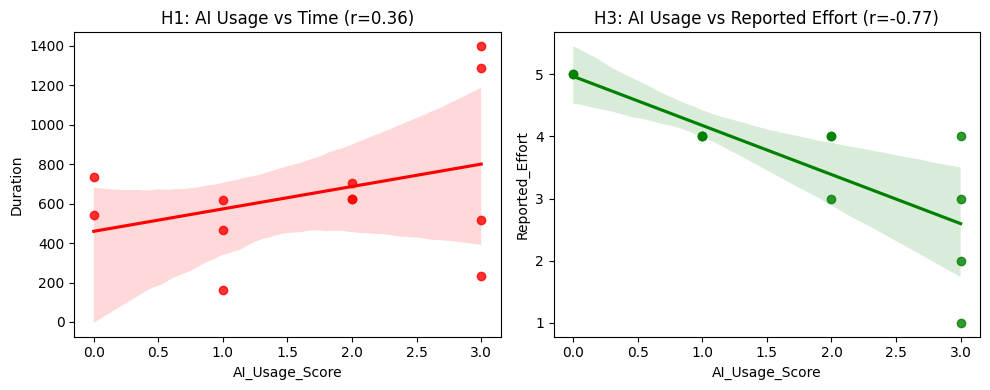

Key Findings:
1. Coordination Cost: Higher AI usage increases task duration (r=0.36).
2. Delegation Effect: Higher AI usage reduces answer length (r=-0.18).
3. Efficiency Illusion: Higher AI usage drastically lowers perceived difficulty (r=-0.77).


In [ ]:
# @title Phase 4: Behavioral Validation (The Beer Game)
# Purpose: Validate if AI usage creates an "Efficiency Illusion" using empirical game data.

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data
path_game = '/content/drive/MyDrive/Research/2025 Beacon/202601 Workshop results/Beer fermentation game with AI - DE(1-12).xlsx'

try:
    # Corrected method to read_excel
    df_game = pd.read_excel(path_game)
    print("Successfully loaded game data.")

    # 2. Preprocessing
    # Calculate Duration (Seconds)
    df_game['Start time'] = pd.to_datetime(df_game['Start time'])
    df_game['Completion time'] = pd.to_datetime(df_game['Completion time'])
    df_game['Duration'] = (df_game['Completion time'] - df_game['Start time']).dt.total_seconds()

    # Calculate AI Usage (Count of "Ja" in Strategy columns)
    ai_cols = [c for c in df_game.columns if 'Strategie' in c and 'Möchten' in c]
    df_game['AI_Usage_Score'] = df_game[ai_cols].apply(lambda x: x.str.contains('Ja', na=False).sum(), axis=1)

    # Calculate Text Effort (Average Length of Answers)
    text_cols = [c for c in df_game.columns if 'Ihre Analyse' in c]
    df_game['Avg_Text_Length'] = df_game[text_cols].fillna('').apply(
        lambda x: np.mean([len(str(s)) for s in x if str(s) != '']), axis=1
    )

    # Get Perceived Effort (Scale 1-7)
    effort_col = [c for c in df_game.columns if 'Wie einfach' in c][0]
    df_game['Reported_Effort'] = pd.to_numeric(df_game[effort_col], errors='coerce')

    # 3. Correlation Matrix
    vars_of_interest = ['Duration', 'AI_Usage_Score', 'Avg_Text_Length', 'Reported_Effort']
    corr_matrix = df_game[vars_of_interest].corr()

    # 4. Visualization
    plt.figure(figsize=(10, 4))

    # Plot 1: The "Cost" of AI (Time)
    plt.subplot(1, 2, 1)
    sns.regplot(data=df_game, x='AI_Usage_Score', y='Duration', color='red')
    plt.title(f"H1: AI Usage vs Time (r={corr_matrix.loc['Duration','AI_Usage_Score']:.2f})")

    # Plot 2: The "Illusion" of AI (Effort)
    plt.subplot(1, 2, 2)
    sns.regplot(data=df_game, x='AI_Usage_Score', y='Reported_Effort', color='green')
    plt.title(f"H3: AI Usage vs Reported Effort (r={corr_matrix.loc['Reported_Effort','AI_Usage_Score']:.2f})")

    plt.tight_layout()
    plt.show()

    print("Key Findings:")
    print(f"1. Coordination Cost: Higher AI usage increases task duration (r={corr_matrix.loc['Duration','AI_Usage_Score']:.2f}).")
    print(f"2. Delegation Effect: Higher AI usage reduces answer length (r={corr_matrix.loc['Avg_Text_Length','AI_Usage_Score']:.2f}).")
    print(f"3. Efficiency Illusion: Higher AI usage drastically lowers perceived difficulty (r={corr_matrix.loc['Reported_Effort','AI_Usage_Score']:.2f}).")

except Exception as e:
    print(f"Error processing game data: {e}")